In [172]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import skimage
from skimage.segmentation import mark_boundaries, slic, watershed
from skimage import filters
from skimage.measure import regionprops_table, perimeter#, regionprops
from skimage.util import map_array
import pandas as pd

In [203]:
path = "data/sample3.tif"

In [204]:
with rasterio.open(path) as src:
    # Extract red, green, blue, and NIR bands, normalize to [0, 1]
    bands = src.read([1, 2, 3]).astype(float) / 255
    red, green, blue = bands

In [205]:
rgb = np.stack([red, green, blue], axis=-1)

In [206]:
with rasterio.open(path) as dataset:
  print(dataset.profile)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1164, 'height': 877, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 54N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",141],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32654"]]'), 'transform': Affine(2.40000000000003, 0.0, 375141.6,
       0.0, -2.3999999999997876, 3908606.4), 'blockxsize': 1164, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}


In [207]:
print('Image has a shape of: ',rgb.shape)
print('And a size of: ',rgb.size)

Image has a shape of:  (877, 1164, 3)
And a size of:  3062484


In [208]:
def plot_rgb(rgb):
  plt.imshow(rgb)
  plt.show()

def display_image(image,zoom=1.0):
  plt.figure(figsize=(6, 6))
  plt.imshow(image, extent=[0, zoom * image.shape[1], 0, zoom * image.shape[0]])
  plt.axis('off')
  plt.show()

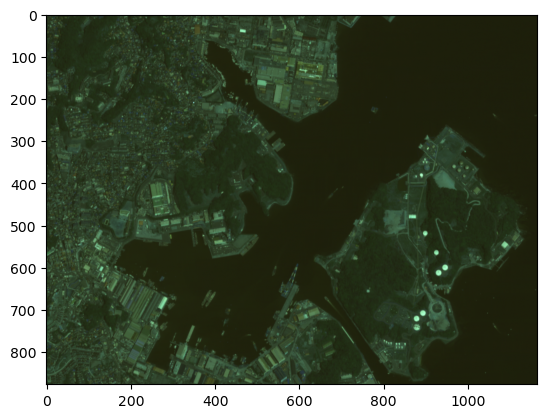

In [209]:
plot_rgb(rgb)

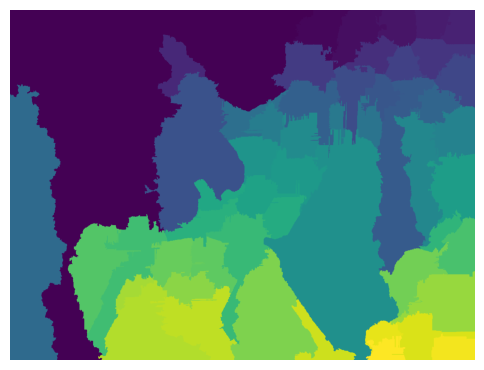

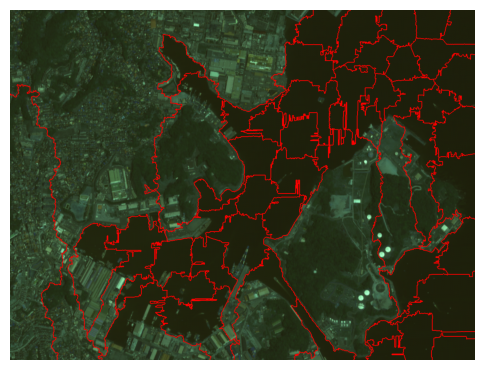

In [210]:
seg = slic(rgb, n_segments=250, compactness=0.5, start_label=1)
bound = mark_boundaries(rgb, seg, color=(1, 0, 0), mode="thick")
display_image(seg)
display_image(bound)

In [211]:
opened = skimage.morphology.opening(skimage.color.rgb2gray(rgb), skimage.morphology.disk(1))
closed = skimage.morphology.closing(opened, skimage.morphology.disk(1))

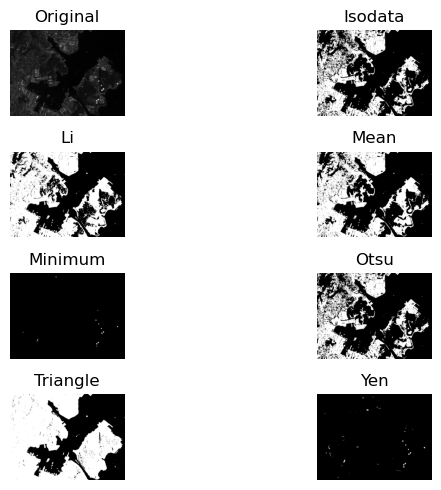

In [212]:
filters.try_all_threshold(opened, verbose=False)
plt.show()

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


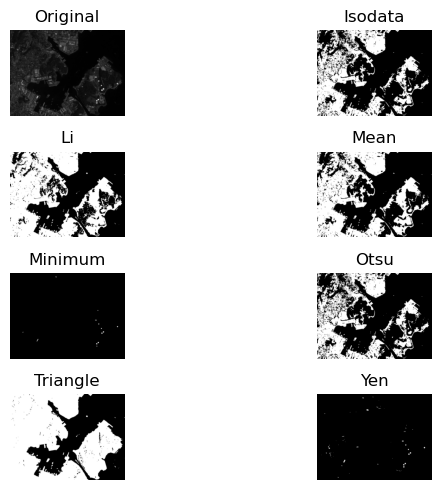

In [213]:
filters.try_all_threshold(closed, verbose=True)
plt.show()

In [214]:
edge_roberts = roberts(skimage.color.rgb2gray(rgb)) #Roberts
# edge_sobel = sobel(skimage.color.rgb2gray(rgb)) #Sobel
# canny = canny(skimage.color.rgb2gray(rgb), sigma=1) #Canny
thrsehold_triangle = closed < filters.threshold_triangle(closed) # Threshold



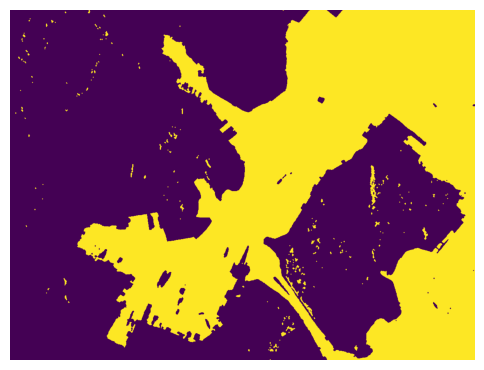

In [215]:
display_image(thrsehold_triangle)

In [216]:
canny = skimage.feature.canny(skimage.color.rgb2gray(rgb))
sobel = skimage.filters.sobel(skimage.color.rgb2gray(rgb))
thrsehold_triangle = closed < filters.threshold_triangle(closed)
markers=2100
# Generate segments using Watershed
wth_canny_segments = watershed( canny,
                                markers=markers,
                                #compactness=compactness
                                )

wth_thre_segments = watershed(thrsehold_triangle,
                              markers= 1500,
                              compactness=0.0001
)

wth_sobel_segments = watershed(sobel,
                              markers= markers
)

wth_segments = watershed(skimage.color.rgb2gray(rgb),
                              markers= markers
)

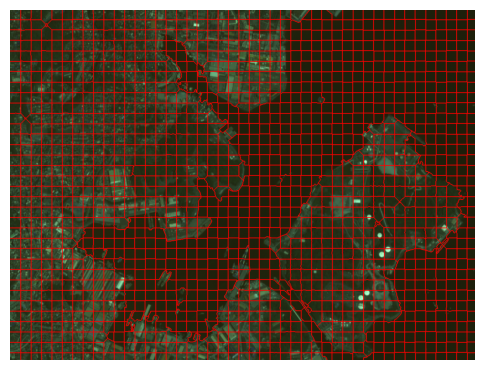

In [217]:
display_image(mark_boundaries(rgb, wth_thre_segments, color=(1, 0, 0), mode="thick"))

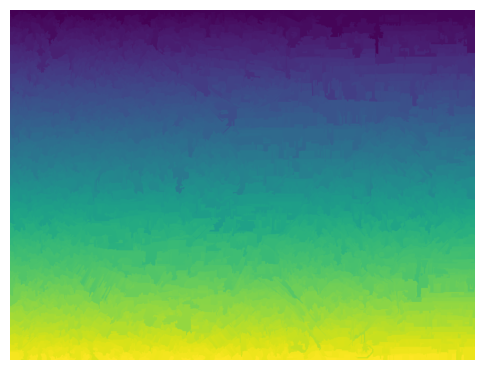

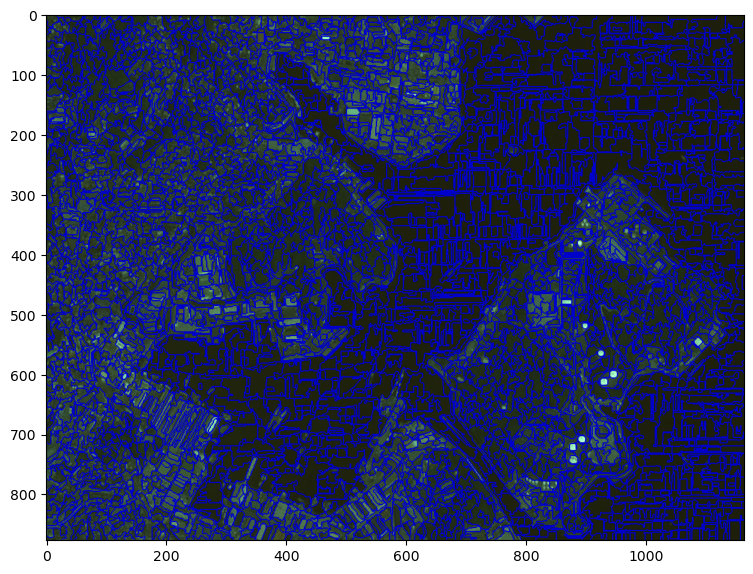

In [218]:
from skimage.segmentation import felzenszwalb

felz_segments = felzenszwalb(rgb,
                        scale=3.0,
                        sigma=0.95,
                        min_size=50)

display_image(felz_segments)
#Visualizing
with plt.ion():
  plt.figure(figsize=(9,9))
  plt.imshow(mark_boundaries(rgb, felz_segments, color=(0,0,0.8), mode="thick"))

In [219]:
# Define custom features
def std(regionmask, intensity_img):
    vals = intensity_img[regionmask]
    std = np.std(vals)
    return std

def rectangularity(regionmask):
    return regionmask.sum()/regionmask.size

def compactness(regionmask):
    return 4*np.pi*regionmask.sum()/(perimeter(regionmask)**2 + 1e-6)  # small value added to avoid division by zero


# Calculate set of various features for each segment
def calc_all_feats(seg_arr, img_arr):
    spectral_feats = pd.DataFrame(
        regionprops_table(
            label_image = seg_arr,
            intensity_image = img_arr,
            properties = ["label", "intensity_mean"],
            extra_properties=(std,)
        )
    )
    shape_feats = pd.DataFrame(
        regionprops_table(
            label_image = seg_arr,
            properties = ["solidity","area","perimeter"],
            extra_properties=(rectangularity, compactness)
        )
    )

    #JOIN
    all_feats = pd.concat([spectral_feats, shape_feats], axis=1)

    return all_feats

In [220]:
all_feats_df = calc_all_feats(felz_segments, rgb)
all_feats_df = all_feats_df.rename(columns={'label': 'indx'})

## Create a new column
all_feats_df['log_area'] = np.log1p(all_feats_df['area'])


display(all_feats_df)

,indx,intensity_mean-0,intensity_mean-1,intensity_mean-2,std-0,std-1,std-2,solidity,area,perimeter,rectangularity,compactness,log_area
0,1,0.149955,0.199832,0.107838,0.024637,0.036236,0.031396,0.827051,373.0,109.870058,0.740079,0.388293,5.924256
1,2,0.130558,0.171342,0.079155,0.002548,0.010248,0.005953,0.427632,65.0,48.727922,0.244361,0.344007,4.189655
2,3,0.131299,0.172962,0.084034,0.004012,0.006474,0.005318,0.585903,133.0,66.077164,0.385507,0.382788,4.897840
3,4,0.145514,0.201662,0.106194,0.018680,0.028635,0.025433,0.915152,151.0,48.142136,0.719048,0.818721,5.023881
4,5,0.131328,0.178899,0.087411,0.004074,0.010995,0.008372,0.624113,176.0,79.284271,0.458333,0.351843,5.176150
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4197,4198,0.206994,0.291611,0.185648,0.031095,0.056994,0.043054,0.836207,97.0,44.727922,0.633987,0.609290,4.584967
4198,4199,0.152005,0.211007,0.118494,0.009403,0.019890,0.016065,0.888889,88.0,39.656854,0.733333,0.703163,4.488636
4199,4200,0.195571,0.277755,0.174070,0.022442,0.035828,0.026093,0.778523,116.0,59.727922,0.517857,0.408614,4.762174
4200,4201,0.174833,0.243213,0.151761,0.011031,0.016914,0.015182,0.691275,103.0,57.763456,0.613095,0.387919,4.644391


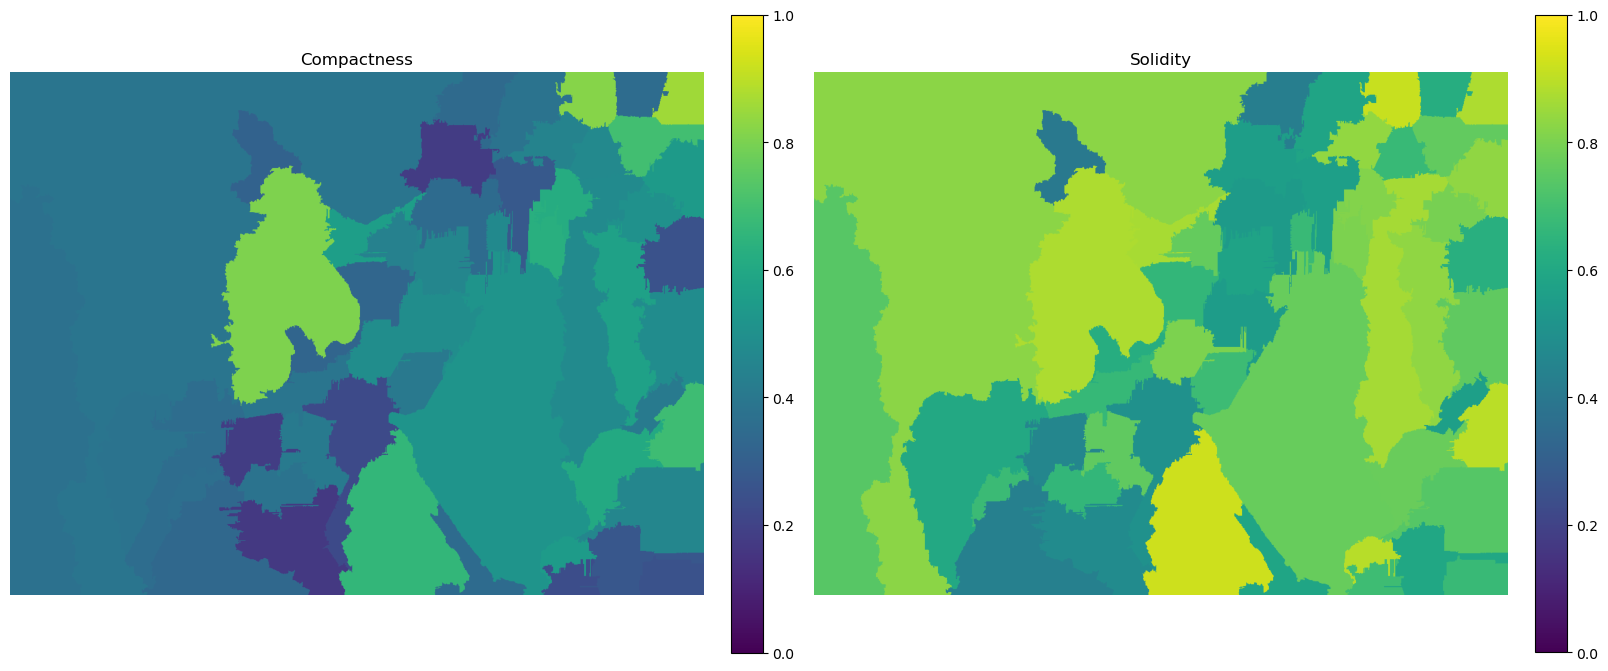

In [221]:
# Map compactness and solidity values back to their corresponding segments in the image
mapped_compactness = map_array(seg, np.array(all_feats_df["indx"]), np.array(all_feats_df["compactness"]))
mapped_solidity = map_array(seg, np.array(all_feats_df["indx"]), np.array(all_feats_df["solidity"]))

#Display Original RGB, Compactness, and Solidity
fig, axs = plt.subplots(ncols=2, figsize=(16,16), constrained_layout=True)
im1=axs[0].imshow(mapped_compactness, vmin = 0,
                                      vmax= 1)

im2=axs[1].imshow(mapped_solidity, vmin = 0, vmax=1)
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)

axs[0].set_title("Compactness")
axs[1].set_title("Solidity")

for ax in axs.flat:
    ax.set_axis_off();

# Show the plots
plt.show()

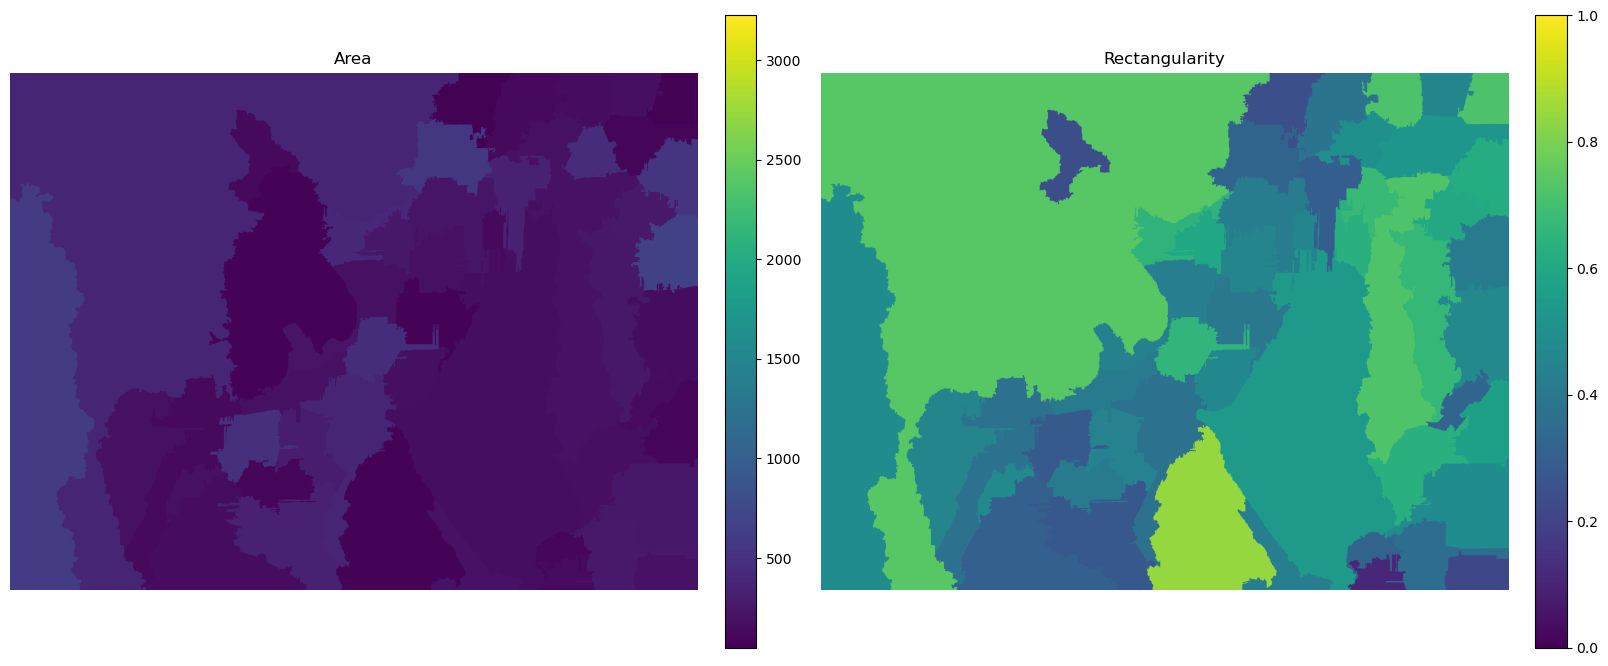

In [222]:
# Map compactness and solidity values back to their corresponding segments in the image
mapped_area = map_array(seg, np.array(all_feats_df["indx"]), np.array(all_feats_df["area"]))
mapped_log_area = map_array(seg, np.array(all_feats_df["indx"]), np.array(all_feats_df["log_area"]))
mapped_rectangularity = map_array(seg, np.array(all_feats_df["indx"]), np.array(all_feats_df["rectangularity"]))

#Display Original RGB, Compactness, and Solidity
fig, axs = plt.subplots(ncols=2, figsize=(16,16), constrained_layout=True)
im1=axs[0].imshow(mapped_area, vmin = int(all_feats_df['area'].min()),
                                      vmax= int(all_feats_df['area'].max()))
im2=axs[1].imshow(mapped_rectangularity, vmin = 0, vmax=1)
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)

axs[0].set_title("Area")
axs[1].set_title("Rectangularity")

for ax in axs.flat:
    ax.set_axis_off();

# Show the plots
plt.show()


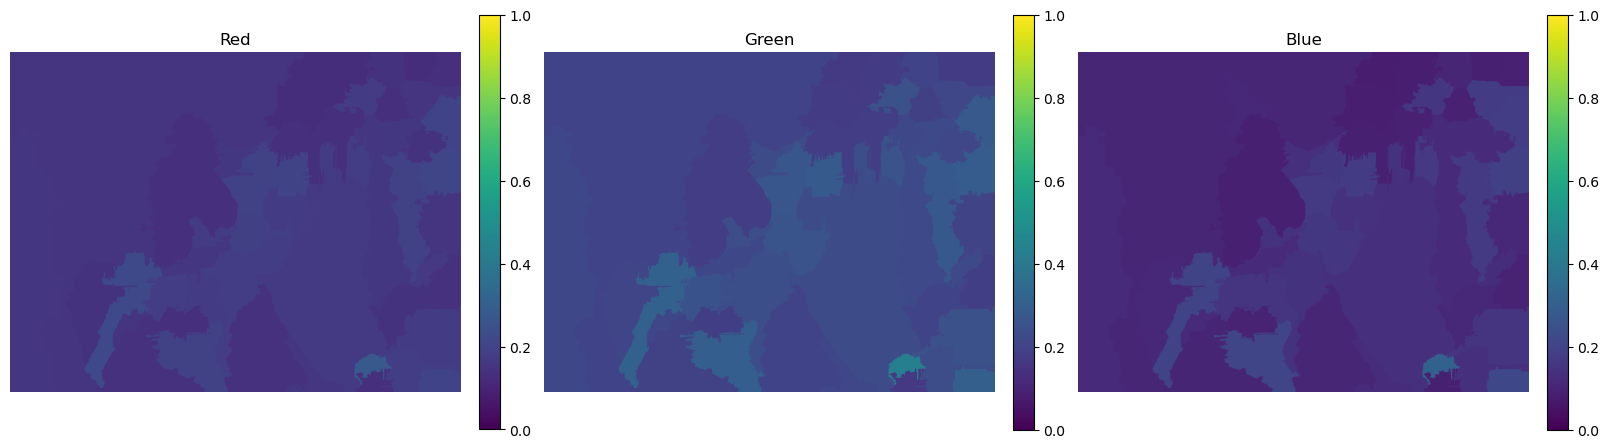

In [224]:
# Mapping R intensity mean
mapped_mean_red = map_array(
    seg,
    np.array(all_feats_df["indx"]),
    np.array(all_feats_df["intensity_mean-0"])
)

# Mapping Green intensity mean
mapped_mean_green = map_array(
    seg,
    np.array(all_feats_df["indx"]),
    np.array(all_feats_df["intensity_mean-1"])
)

# Mapping Blue intensity mean
mapped_mean_blue = map_array(
    seg,
    np.array(all_feats_df["indx"]),
    np.array(all_feats_df["intensity_mean-2"])
)

# Mapping Blue intensity mean
mapped_std_red = map_array(
    seg,
    np.array(all_feats_df["indx"]),
    np.array(all_feats_df["std-0"])
)

## Plot
#Display R G B intensity
fig, axs = plt.subplots(ncols=3, figsize=(16,16), constrained_layout=True)
im1=axs[0].imshow(mapped_mean_red, vmin = 0,
                                      vmax= 1)
im2=axs[1].imshow(mapped_mean_green, vmin = 0, vmax=1)
im3=axs[2].imshow(mapped_mean_blue, vmin = 0, vmax=1)

fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
fig.colorbar(im3, ax=axs[2], fraction=0.046, pad=0.04)

axs[0].set_title("Red")
axs[1].set_title("Green")
axs[2].set_title("Blue")

for ax in axs.flat:
    ax.set_axis_off();

# Show the plots
plt.show()